Chapter 30
# 多项式回归 + 岭回归正则化
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [37]:
# 导入包
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [39]:
# 生成随机数据
np.random.seed(0)
num = 30

In [41]:
X = np.random.uniform(0,4,num)
y = np.sin(0.4*np.pi * X) + 0.4 * np.random.randn(num)
data = np.column_stack([X,y])

In [43]:
x_array = np.linspace(0,4,101).reshape(-1,1)
degree = 12 # 多项式回归次数
# 将数据扩展为13列
poly = PolynomialFeatures(degree = degree)
X_poly = poly.fit_transform(X.reshape(-1, 1))
    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.16036e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.50203e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.39374e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


$y = -1.404 + 22.148x^1 -66.254x^2 + 52.343x^3 + 32.114x^4 -48.380x^5 -18.463x^6 + 56.201x^7 -39.221x^8 + 14.103x^9 -2.871x^10 + 0.315x^11 -0.015x^12$
$y = -0.634 + 11.260x^1 -29.034x^2 + 16.024x^3 + 15.384x^4 -11.459x^5 -9.661x^6 + 12.298x^7 -4.519x^8 + 0.397x^9 + 0.154x^10 -0.042x^11 + 0.003x^12$
$y = 0.322 + 0.139x^1 -0.662x^2 + 1.049x^3 + 1.161x^4 -0.339x^5 -1.307x^6 -0.075x^7 + 1.312x^8 -0.907x^9 + 0.274x^10 -0.040x^11 + 0.002x^12$
$y = 0.326 + 0.109x^1 + 0.138x^2 + 0.144x^3 + 0.089x^4 -0.009x^5 -0.082x^6 -0.053x^7 + 0.040x^8 + 0.021x^9 -0.020x^10 + 0.005x^11 -0.000x^12$
$y = 0.421 + 0.039x^1 + 0.056x^2 + 0.063x^3 + 0.053x^4 + 0.023x^5 -0.018x^6 -0.041x^7 -0.011x^8 + 0.040x^9 -0.020x^10 + 0.004x^11 -0.000x^12$
$y = 0.510 + 0.008x^1 + 0.011x^2 + 0.014x^3 + 0.014x^4 + 0.009x^5 + 0.001x^6 -0.006x^7 -0.005x^8 + 0.004x^9 -0.001x^10 + 0.000x^11 -0.000x^12$


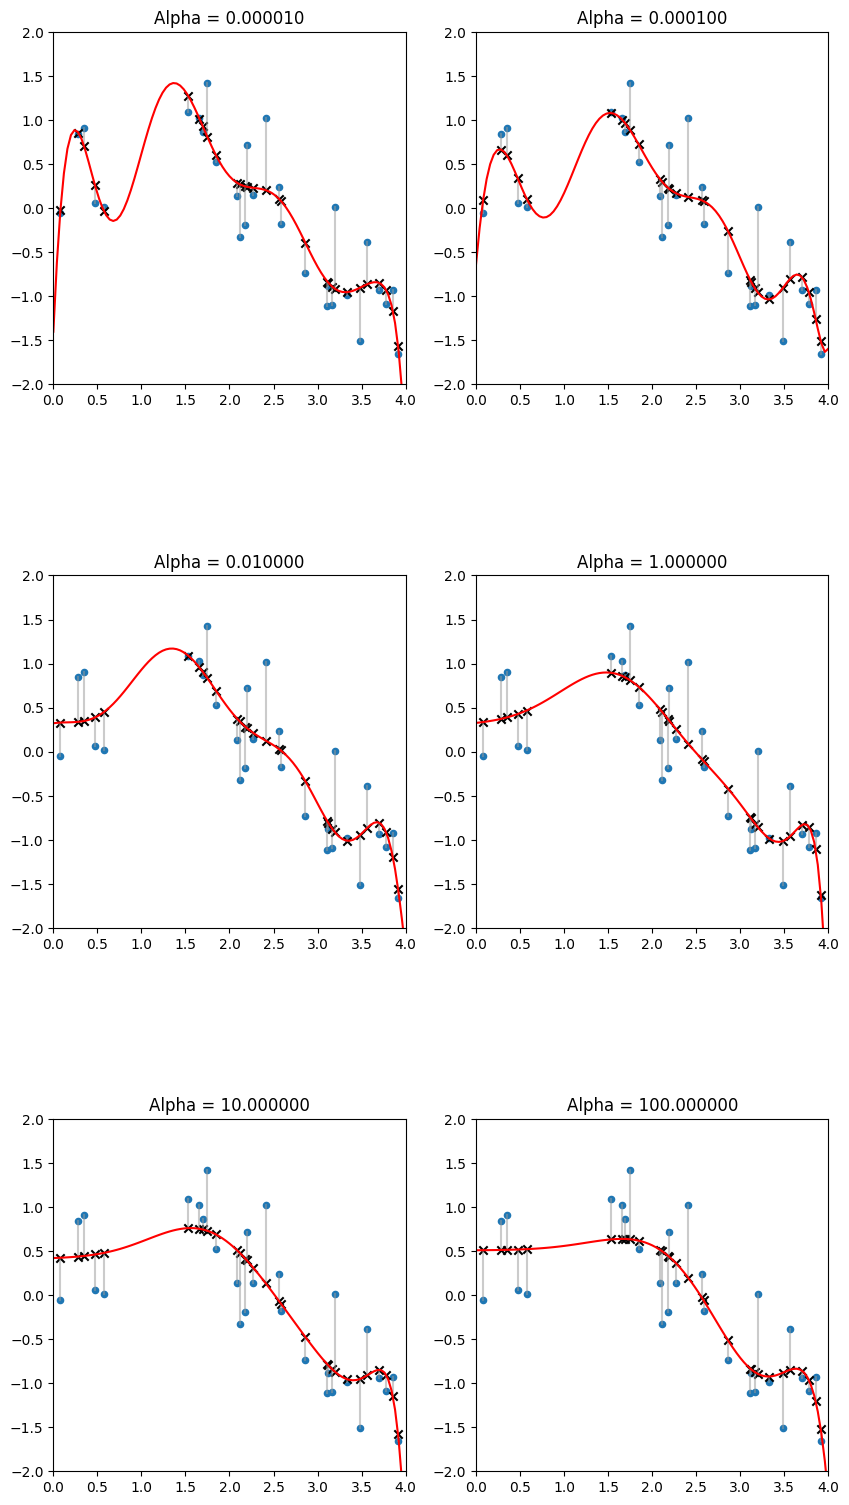

In [50]:
fig, axes = plt.subplots(3,2,figsize=(10,20))
axes = axes.flatten()
# 惩罚因子
alpha_array = [0.00001, 0.0001, 0.01, 1, 10, 100]

for ax, alpha_idx in zip(axes,alpha_array):

    # 训练岭回归模型
    ridge = Ridge(alpha=alpha_idx)
    ridge.fit(X_poly, y.reshape(-1,1))
    # 预测
    y_array_pred = ridge.predict(poly.fit_transform(x_array))    
    y_poly_pred  = ridge.predict(X_poly)
    data_ = np.column_stack([X,y_poly_pred])
    # 绘制散点图
    ax.scatter(X, y, s=20)
    ax.scatter(X, y_poly_pred, marker = 'x', color='k')
    # 绘制残差
    ax.plot(([i for (i,j) in data_], [i for (i,j) in data]),
            ([j for (i,j) in data_], [j for (i,j) in data]),
             c=[0.6,0.6,0.6], alpha = 0.5)
    
    ax.plot(x_array, y_array_pred, color='r')
    ax.set_title('Alpha = %f' % alpha_idx)
    
    # 提取参数
    coef = ridge.coef_[0]; # print(coef)
    intercept = ridge.intercept_[0]; # print(intercept)
    # 回归解析式
    equation = '$y = {:.3f}'.format(intercept)
    for j in range(1, len(coef)):
        equation += ' + {:.3f}x^{}'.format(coef[j], j)
    equation += '$'
    equation = equation.replace("+ -", "-")
    print(equation)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0,4); ax.set_ylim(-2,2); ax.grid(False)

In [52]:
# 多项式回归模型参数随惩罚因子α变化
alphas = np.logspace(4, -2, 100)
#range(13)生成1到12的整数
degrees = ['Degree = ' + str(d_i) for d_i in range(13)]
colors = plt.cm.jet(np.linspace(0,1,len(degrees)))

In [54]:
coefs = []
for alpha_idx in alphas:
    ridge = Ridge(alpha=alpha_idx)
    ridge.fit(X_poly, y.reshape(-1,1))
    coefs.append(ridge.coef_[0])
coefs = np.array(coefs)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.00275e-16): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=8.72142e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=7.58545e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.59744e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.

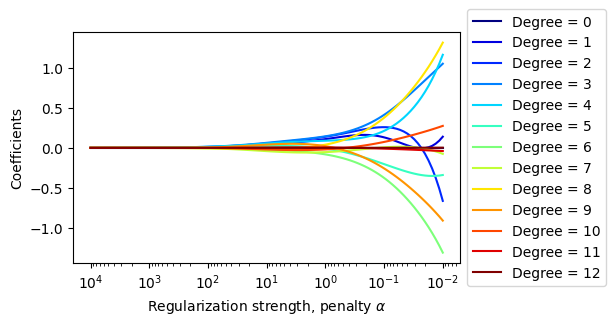

In [56]:
fig, ax = plt.subplots(figsize=(5,3))
for idx in range(13):
    ax.plot(alphas, coefs[:,idx], color = colors[idx])
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1]) # 调转横轴
ax.set_xlabel(r"Regularization strength, penalty $\alpha$")
ax.set_ylabel("Coefficients")
ax.legend(degrees,loc='center left', bbox_to_anchor=(1, 0.5))